# FinBert -- Final Project
## Dataset -- Financial PhraseBank
## Link : takala/financial_phrasebank


**Import Libraries**

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)


**Load Financial Phrase Bank Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()  # file selector


Saving Sentences_AllAgree.txt to Sentences_AllAgree.txt


In [ ]:
rows = []
with open("/content/Sentences_AllAgree.txt", encoding="iso-8859-1") as f:
    for line in f:
        sentence, label = line.rsplit("@", 1)
        rows.append({"sentence": sentence.strip(), "label": label.strip()})

df = pd.DataFrame(rows)
df["label"] = df["label"].map({
    "positive":0,
    "negative":1,
    "neutral": 2
})
#dataset = datasets.Dataset.from_pandas(df)
df.head()

,sentence,label
0,"According to Gran , the company has no plans t...",2
1,"For the last quarter of 2010 , Componenta 's n...",0
2,"In the third quarter of 2010 , net sales incre...",0
3,Operating profit rose to EUR 13.1 mn from EUR ...,0
4,"Operating profit totalled EUR 21.1 mn , up fro...",0


**Split Dataset**

In [ ]:
# Convert to DataFrame for splitting

#df = dataset.to_pandas()
#df = df.dropna().reset_index(drop=True)

from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Model 1 - Finetune FinBERT Model

**Load FinBERT**

In [ ]:
finbert_name = "yiyanghkust/finbert-tone"
finbert_tokenizer = AutoTokenizer.from_pretrained(finbert_name)
finbert_model = AutoModelForSequenceClassification.from_pretrained(finbert_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

**Tokenize Dataset**

In [ ]:
def tokenize_finbert(examples):
    return finbert_tokenizer(examples["sentence"], padding="max_length", max_length=128)

tokenized_train = train_dataset.map(tokenize_finbert, batched=True)
tokenized_test = test_dataset.map(tokenize_finbert, batched=True)


Map:   0%|          | 0/1811 [00:00<?, ? examples/s]

Map:   0%|          | 0/453 [00:00<?, ? examples/s]

In [ ]:
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_test  = tokenized_test.rename_column("label", "labels")

tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

**Set up Trainer**

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(finbert_name, num_labels=3)


# 5. Training args
training_args = TrainingArguments(
    output_dir="./finbert",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8
)

# 6. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=finbert_tokenizer
)

# 7. Train
trainer.train()

# 8. Evaluate
preds = trainer.predict(tokenized_test)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

/tmp/ipython-input-217037158.py:13: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


KeyboardInterrupt: 

**Compute Compute Matrix + Classification Report**

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["negative", "neutral", "positive"], yticklabels=["negative", "neutral", "positive"])
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


FinBERT Accuracy: 0.9735099337748344
              precision    recall  f1-score   support

    negative       0.96      0.95      0.95       114
     neutral       0.98      0.93      0.96        61
    positive       0.98      0.99      0.99       278

    accuracy                           0.97       453
   macro avg       0.97      0.96      0.97       453
weighted avg       0.97      0.97      0.97       453



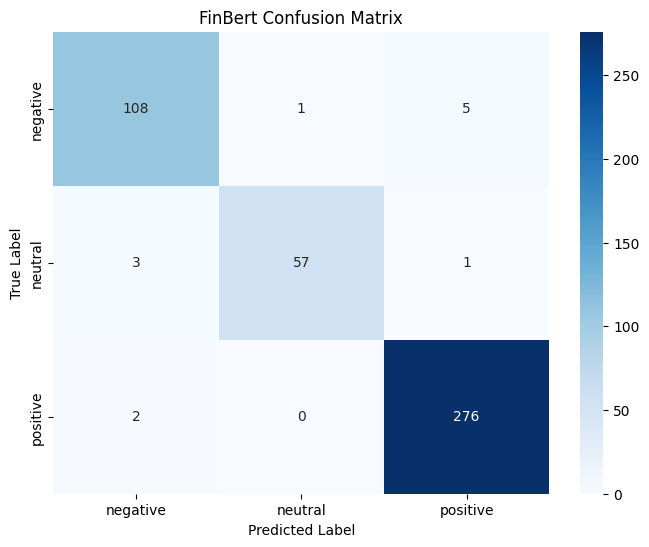

In [ ]:
preds = trainer.predict(tokenized_test)
finbert_y_pred = np.argmax(preds.predictions, axis=1)
finbert_y_true = preds.label_ids

print("FinBERT Accuracy:", accuracy_score(finbert_y_true, finbert_y_pred))
print(classification_report(finbert_y_true, finbert_y_pred, target_names=["negative","neutral","positive"]))
plot_confusion_matrix(finbert_y_true, finbert_y_pred, "FinBert Confusion Matrix")

In [ ]:
# Folder to save model & tokenizer
finbert_model_path = "/content/finbert_sentiment_saved"

# Save model & tokenizer
trainer.model.save_pretrained(finbert_model_path)
trainer.tokenizer.save_pretrained(finbert_model_path)

import shutil

shutil.make_archive("/content/finbert_sentiment_saved", 'zip', finbert_model_path)


NameError: name 'trainer' is not defined

In [ ]:
from google.colab import files

# This will open a file picker
uploaded = files.upload()


Saving finbert_sentiment_saved.zip to finbert_sentiment_saved.zip


In [ ]:
!unzip finbert_sentiment_saved.zip -d ./finbert_model


Archive:  finbert_sentiment_saved.zip
  inflating: ./finbert_model/config.json  
  inflating: ./finbert_model/model.safetensors  
  inflating: ./finbert_model/vocab.txt  
  inflating: ./finbert_model/tokenizer.json  
  inflating: ./finbert_model/special_tokens_map.json  
  inflating: ./finbert_model/tokenizer_config.json  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Then load from Drive
model_path = "/content/drive/MyDrive/finbert_model"


Mounted at /content/drive


## Model 2: Finbert Pre-Trained

In [ ]:
#use pre-trained Finbert model and tokenizer
nlp = pipeline("text-classification", model=finbert_model, tokenizer=finbert_tokenizer)

results = nlp(df["sentence"].to_list())

Device set to use cpu


In [ ]:
predicted_labels_finbert = [r['label'] for r in results]
label_mapping = {
    "Positive": 0,
    "Negative": 1,
    "Neutral": 2
}

mapped_predicted_labels_finbert = [label_mapping[label] for label in predicted_labels_finbert]

print("FinBERT Accuracy:", accuracy_score(df["label"], mapped_predicted_labels_finbert))
print(classification_report(df["label"], mapped_predicted_labels_finbert, target_names=["positive","negative","neutral"]))

FinBERT Accuracy: 0.9169611307420494
              precision    recall  f1-score   support

    positive       0.96      0.74      0.84       570
    negative       0.89      0.93      0.91       303
     neutral       0.91      0.99      0.95      1391

    accuracy                           0.92      2264
   macro avg       0.92      0.89      0.90      2264
weighted avg       0.92      0.92      0.91      2264



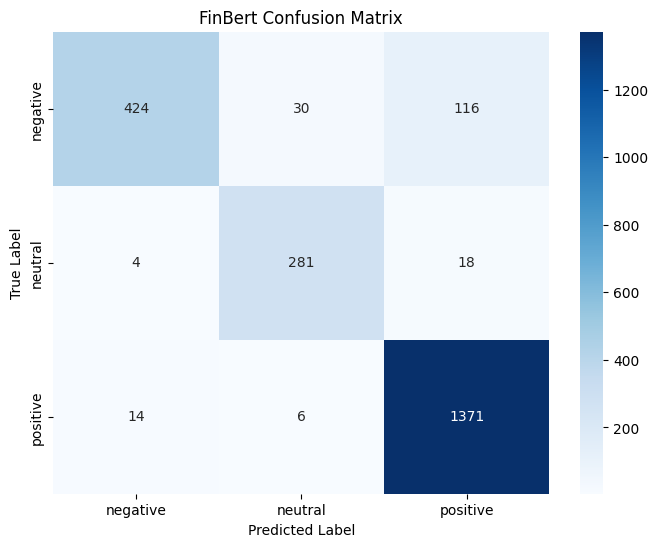

In [ ]:
plot_confusion_matrix(df["label"], mapped_predicted_labels_finbert, "FinBert Confusion Matrix")

# Model 2 — BERT-base-uncased (Fine-Tune)

**Load Bert Model**

In [ ]:
bert_name = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_name)
bert_model = AutoModelForSequenceClassification.from_pretrained(bert_name, num_labels=3)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**Tokenize Dataset**

In [ ]:
def tokenize_bert(batch):
    return bert_tokenizer(batch["sentence"], truncation=True)

tokenized_train_bert = train_dataset.map(tokenize_bert, batched=True)
tokenized_test_bert = test_dataset.map(tokenize_bert, batched=True)

#tokenized_bert = tokenized_train_bert.train_test_split(test_size=0.2, seed=42)

Map:   0%|          | 0/1811 [00:00<?, ? examples/s]

Map:   0%|          | 0/453 [00:00<?, ? examples/s]

**Set up Trainer**

In [ ]:
bert_data_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)

#  Training args
training_args = TrainingArguments(
    output_dir="./bert",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    seed=42,
    data_seed=42
)

bert_trainer = Trainer(
    model=bert_model,
    args=training_args,
    tokenizer=bert_tokenizer,
    data_collator=bert_data_collator,
    compute_metrics=compute_metrics,
)

bert_preds = bert_trainer.predict(tokenized_test_bert)
bert_y_pred = np.argmax(bert_preds.predictions, axis=1)
bert_y_true = bert_preds.label_ids


/tmp/ipython-input-1370853429.py:13: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  bert_trainer = Trainer(


**Compute Confusion Matrix + Classification Report**

BERT Accuracy: 0.7682119205298014
              precision    recall  f1-score   support

    negative       0.54      0.72      0.62       114
     neutral       0.00      0.00      0.00        61
    positive       0.88      0.96      0.92       278

    accuracy                           0.77       453
   macro avg       0.47      0.56      0.51       453
weighted avg       0.68      0.77      0.72       453



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


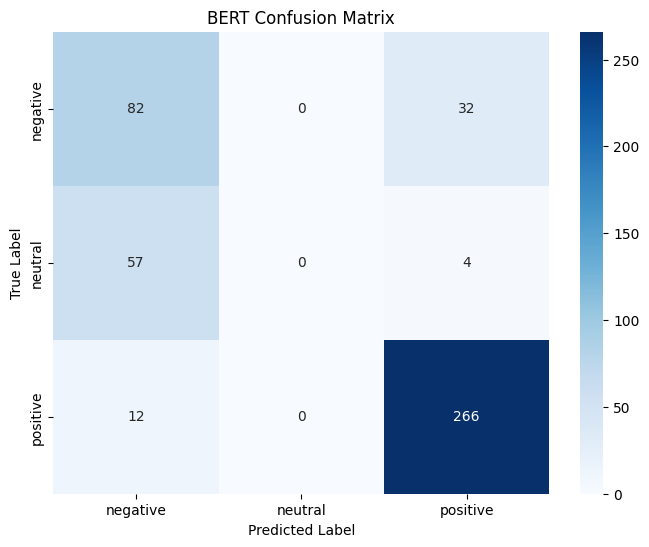

In [ ]:
print("BERT Accuracy:", accuracy_score(bert_y_true, bert_y_pred))
print(classification_report(bert_y_true, bert_y_pred, target_names=["negative","neutral","positive"]))
plot_confusion_matrix(bert_y_true, bert_y_pred, "BERT Confusion Matrix")

# Model : BERT Pre-Trained

In [ ]:
nlp = pipeline("text-classification", model=bert_model, tokenizer=bert_tokenizer)

results = nlp(df["sentence"].to_list())

Device set to use cpu


BERT Accuracy: 0.5896643109540636
              precision    recall  f1-score   support

    positive       0.00      0.00      0.00       570
    negative       0.04      0.01      0.02       303
     neutral       0.61      0.96      0.74      1391

    accuracy                           0.59      2264
   macro avg       0.22      0.32      0.25      2264
weighted avg       0.38      0.59      0.46      2264



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


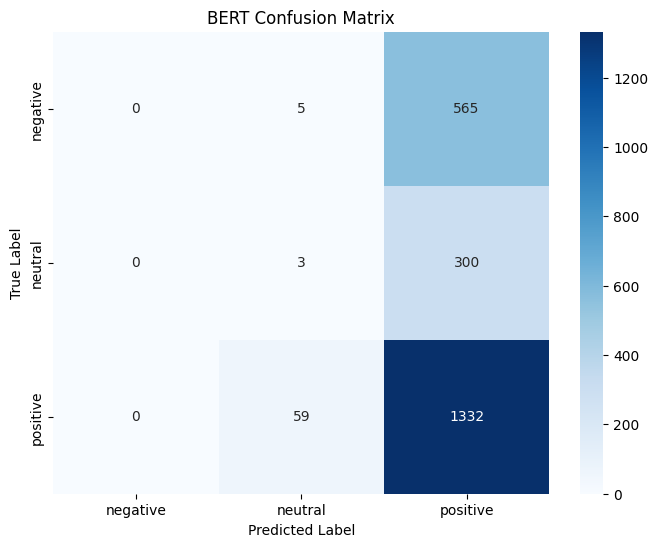

In [ ]:
from transformers import set_seed as hf_set_seed
hf_set_seed(42)
predicted_labels_bert = [r['label'] for r in results]
# Map 'LABEL_0', 'LABEL_1', 'LABEL_2' to the numerical labels used in df['label']
# Assuming default mapping: 0 -> positive, 1 -> negative, 2 -> neutral
label_mapping = {
    "LABEL_0": 0, # positive
    "LABEL_1": 1, # negative
    "LABEL_2": 2  # neutral
}

mapped_predicted_labels_bert = [label_mapping[label] for label in predicted_labels_bert]

print("BERT Accuracy:", accuracy_score(df["label"], mapped_predicted_labels_bert))
print(classification_report(df["label"], mapped_predicted_labels_bert, target_names=["positive","negative","neutral"]))
plot_confusion_matrix(df["label"], mapped_predicted_labels_bert, "BERT Confusion Matrix")

In [ ]:
# Save model & tokenizer
bert_model_path = "/content/bert_model_saved"
bert_trainer.model.save_pretrained(bert_model_path)
bert_trainer.tokenizer.save_pretrained(bert_model_path)

import shutil

shutil.make_archive("/content/bert_model_saved", 'zip', bert_model_path)

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


'/content/bert_model_saved.zip'

In [ ]:
!unzip bert_model_saved.zip -d ./bert_model_saved

Archive:  bert_model_saved.zip
replace ./bert_model_saved/tokenizer.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: ./bert_model_saved/tokenizer.json  
replace ./bert_model_saved/model.safetensors? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: ./bert_model_saved/model.safetensors  y
y

replace ./bert_model_saved/vocab.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename:   inflating: ./bert_model_saved/vocab.txt  
replace ./bert_model_saved/special_tokens_map.json? [y]es, [n]o, [A]ll, [N]one, [r]ename:   inflating: ./bert_model_saved/special_tokens_map.json  
replace ./bert_model_saved/tokenizer_config.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: ./bert_model_saved/tokenizer_config.json  
replace ./bert_model_saved/config.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: ./bert_model_saved/config.json  


# Model 3 : ULMFit

epoch,train_loss,valid_loss,accuracy,time
0,0.924733,0.734342,0.758850,01:16


epoch,train_loss,valid_loss,accuracy,time
0,0.666095,0.494313,0.798673,02:54


ULMFiT Accuracy: 0.7986725663716814
              precision    recall  f1-score   support

    negative       0.67      0.67      0.67       125
     neutral       0.44      0.40      0.42        53
    positive       0.92      0.93      0.93       274

    accuracy                           0.80       452
   macro avg       0.68      0.67      0.67       452
weighted avg       0.79      0.80      0.80       452



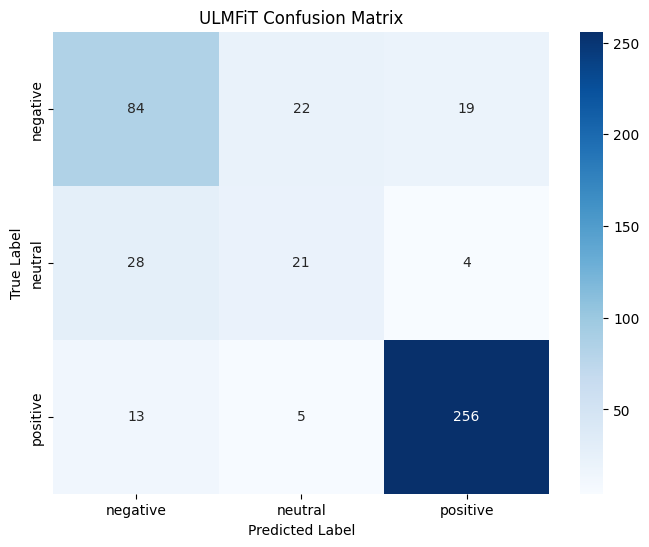

In [ ]:
from fastai.text.all import *

dls = TextDataLoaders.from_df(
    pd.concat([train_df, test_df]),
    text_col='sentence',
    label_col='label',
    valid_pct=0.2,
    text_vocab=None
)

learn = text_classifier_learner(dls, AWD_LSTM, drop_mult=0.5, metrics=accuracy)
learn.fine_tune(1)

ulm_preds, ulm_true = learn.get_preds()
ulm_y_pred = ulm_preds.argmax(dim=1)

print("ULMFiT Accuracy:", accuracy_score(ulm_true, ulm_y_pred))
print(classification_report(ulm_true, ulm_y_pred, target_names=["negative","neutral","positive"]))
plot_confusion_matrix(ulm_true, ulm_y_pred, "ULMFiT Confusion Matrix")


# Model 4 : RoBERTa

**Load Pre-trained RoBerta Model**

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

roberta_name = "cardiffnlp/twitter-roberta-base-sentiment"
roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_name)
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_name)


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
nlp = pipeline(
    "text-classification",
    model=roberta_model,
    tokenizer=roberta_tokenizer,
    return_all_scores=False
)

Device set to use cpu
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


Run RoBERTa Predictions

In [ ]:
results = nlp(df["sentence"].to_list())

In [ ]:
# Model output labels: LABEL_0, LABEL_1, LABEL_2
predicted_labels_str = [r["label"] for r in results]

In [ ]:
# Map RoBERTa Labels
# ------------------------------
roberta_label_map = {
    "LABEL_2": 0,   # positive
    "LABEL_0": 1,   # negative
    "LABEL_1": 2    # neutral
}

mapped_predicted_labels = [roberta_label_map[label] for label in predicted_labels_str]

In [ ]:
# Compute Accuracy
# ------------------------------
print("RoBERTa Accuracy:", accuracy_score(df["label"], mapped_predicted_labels))

print(classification_report(
    df["label"],
    mapped_predicted_labels,
    target_names=["negative", "neutral","positive"]
))

RoBERTa Accuracy: 0.7053886925795053
              precision    recall  f1-score   support

    negative       0.83      0.30      0.44       570
     neutral       0.89      0.26      0.40       303
    positive       0.68      0.97      0.80      1391

    accuracy                           0.71      2264
   macro avg       0.80      0.51      0.55      2264
weighted avg       0.75      0.71      0.66      2264



**Plot Confusion Matrix**

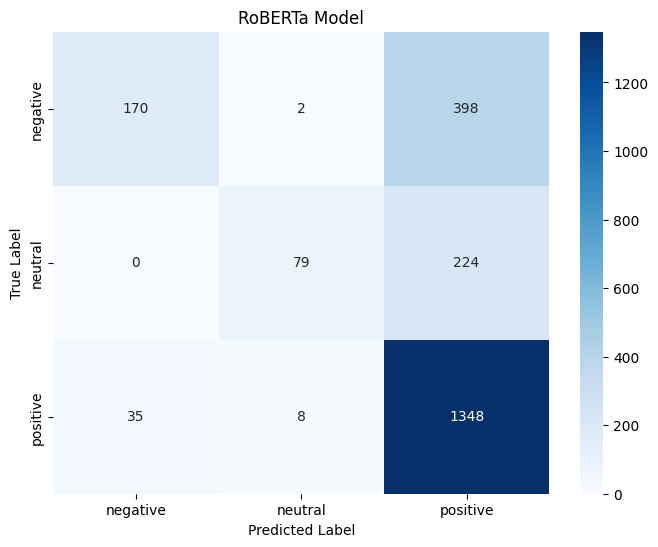

In [ ]:
plot_confusion_matrix(df["label"], mapped_predicted_labels, "RoBERTa Model")


# Comparison Graph of All Models

       Model  Accuracy
0    FinBERT  0.916961
1  BERT-base  0.768212
2    RoBERTa  0.705389
3     ULMFiT  0.798673


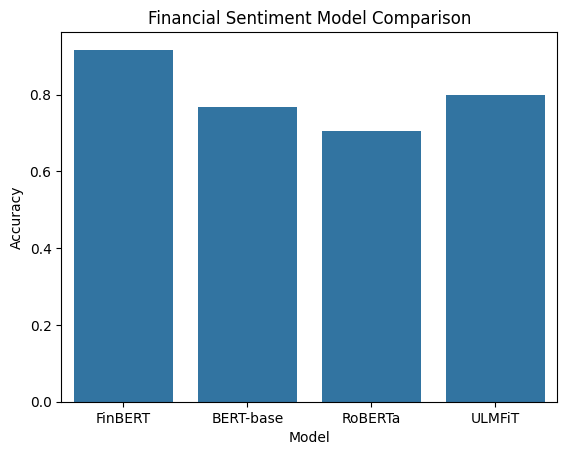

In [ ]:
model_results = {
    "FinBERT": accuracy_score(df["label"], mapped_predicted_labels_finbert),
    "BERT-base": accuracy_score(bert_y_true, bert_y_pred),
    "RoBERTa": accuracy_score(df["label"], mapped_predicted_labels),
    "ULMFiT": accuracy_score(ulm_true, ulm_y_pred)
}

df_results = pd.DataFrame(model_results.items(), columns=["Model", "Accuracy"])
print(df_results)
sns.barplot(x="Model", y="Accuracy", data=df_results)
plt.title("Financial Sentiment Model Comparison")
plt.show()

**Line plot — Confusion Matrix**

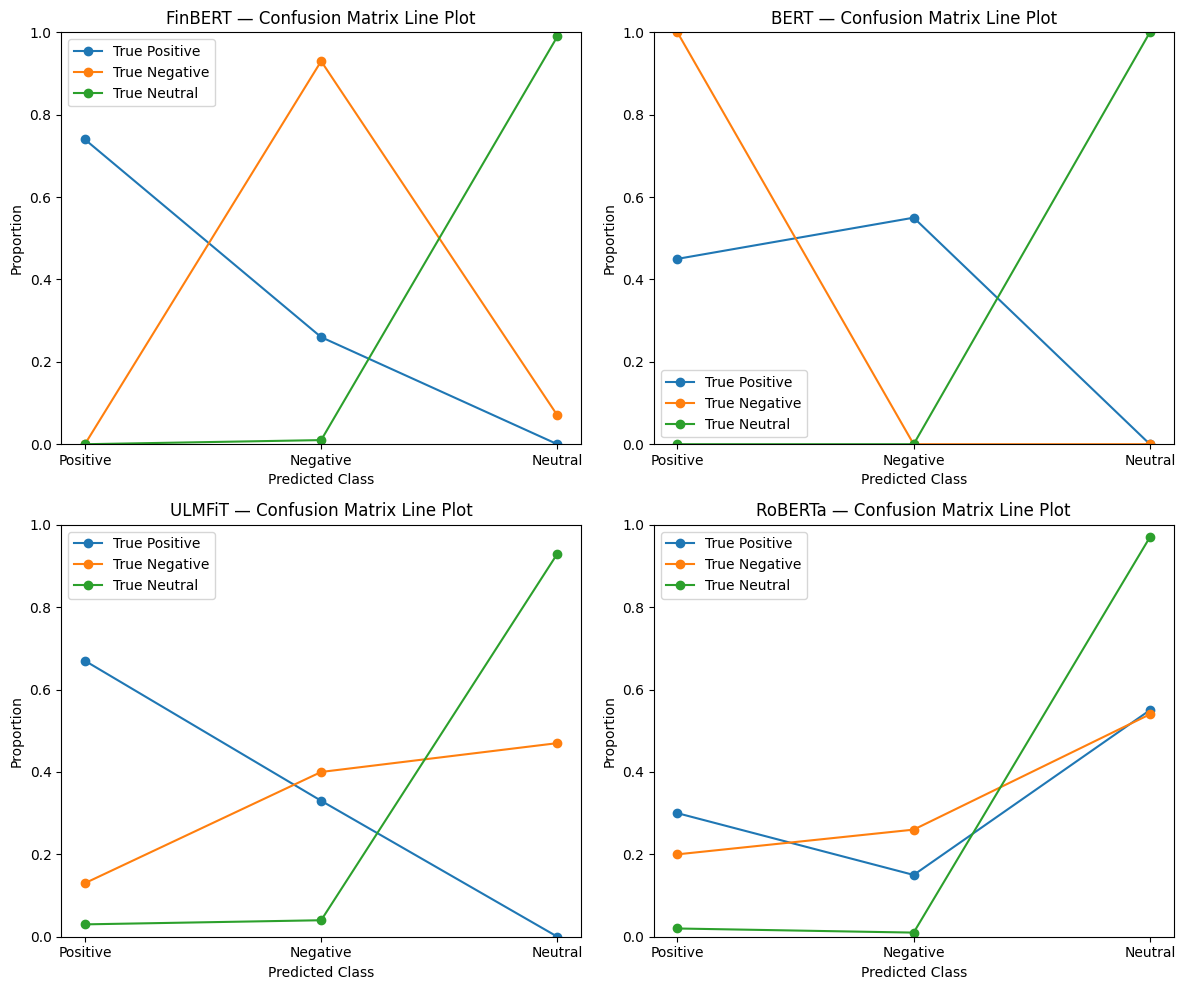

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# CONFUSION MATRICES FROM RESULTS
# ----------------------------

# FinBERT (positive, negative, neutral)
finbert_cm = np.array([
    [0.74, 0.26, 0.00],   # Positive (TP 74%)
    [0.00, 0.93, 0.07],   # Negative
    [0.00, 0.01, 0.99]    # Neutral
])


# BERT
bert_cm = np.array([
    [0.45, 0.55, 0.00],
    [1.00, 0.00, 0.00],
    [0.00, 0.00, 1.00]
])

# ULMFiT
ulmfit_cm = np.array([
    [0.67, 0.33, 0.00],
    [0.13, 0.40, 0.47],
    [0.03, 0.04, 0.93]
])

# RoBERTa
roberta_cm = np.array([
    [0.30, 0.15, 0.55],
    [0.20, 0.26, 0.54],
    [0.02, 0.01, 0.97]
])

# ----------------------------
# PLOT ALL 4 CONFUSION MATRICES
# ----------------------------

models = ["FinBERT", "BERT", "ULMFiT", "RoBERTa"]
matrices = [finbert_cm, bert_cm, ulmfit_cm, roberta_cm]

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

class_labels = ["Positive", "Negative", "Neutral"]

for idx, (model, cm) in enumerate(zip(models, matrices)):
    ax = axs[idx]

    # plot each row (each true label)
    for i in range(cm.shape[0]):
        ax.plot(class_labels, cm[i], marker='o', label=f"True {class_labels[i]}")

    ax.set_title(f"{model} — Confusion Matrix Line Plot")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Proportion")
    ax.legend()

plt.tight_layout()
plt.show()


# Comparison of Model across Metrics

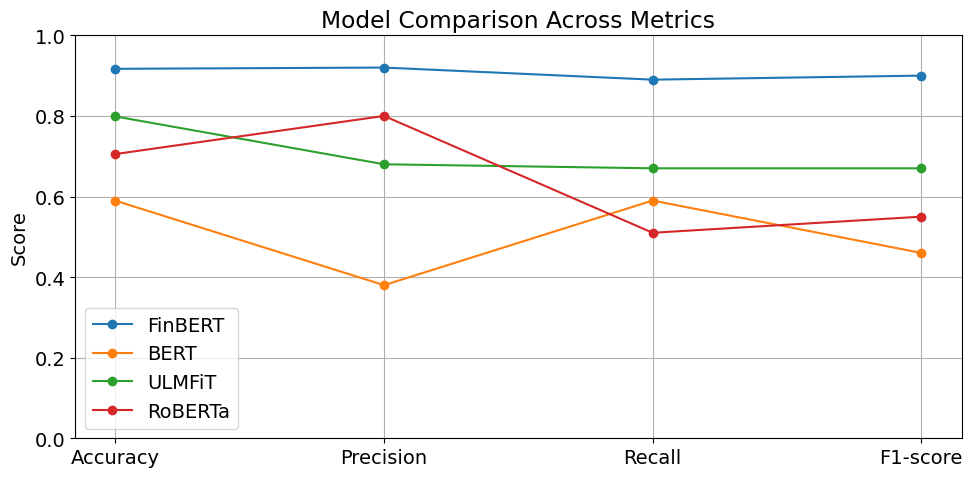

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Set the default font size for all text elements to 14
mpl.rcParams.update({'font.size': 14})

# Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

finbert = [0.9169, 0.92, 0.89, 0.90]
bert = [0.5896, 0.38, 0.59, 0.46]
ulmfit = [0.7987, 0.68, 0.67, 0.67]
roberta = [0.7054, 0.80, 0.51, 0.55]

plt.figure(figsize=(10, 5))

plt.plot(metrics, finbert, marker='o', label="FinBERT")
plt.plot(metrics, bert, marker='o', label="BERT")
plt.plot(metrics, ulmfit, marker='o', label="ULMFiT")
plt.plot(metrics, roberta, marker='o', label="RoBERTa")

plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
